<a href="https://colab.research.google.com/github/alicee127/AMD-Finding-similar-items/blob/main/finding_similar_items.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finding similar items
## Project for Algorithms for Massive Datasets
### Alice Giardina - Università degli Studi di Milano

In [1]:
import random
from sympy import isprime
import numpy as np
import string
from itertools import combinations
import hashlib
import json

Initialize Spark Session

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
import pyspark
sc = spark.sparkContext

### Load dataset

In [3]:
import os
os.environ['KAGGLE_USERNAME'] = "xxxxxx" #change with Kaggle username
os.environ['KAGGLE_KEY'] = "xxxxxx" #change with Kaggle key
!kaggle datasets download -d benjaminawd/new-york-times-articles-comments-2020

Dataset URL: https://www.kaggle.com/datasets/benjaminawd/new-york-times-articles-comments-2020
License(s): CC-BY-NC-SA-4.0
new-york-times-articles-comments-2020.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import zipfile

path = "dataset/nyt-articles-2020.csv"

if not(os.path.exists(path)):
  with zipfile.ZipFile("new-york-times-articles-comments-2020.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

articles = spark.read.csv(path, header = True)

In [5]:
articles.show(5)

+---------+------------------+----------+-------------------+--------------------+--------------------+--------------------+----------+--------------------+----------+--------------------+
| newsdesk|           section|subsection|           material|            headline|            abstract|            keywords|word_count|            pub_date|n_comments|            uniqueID|
+---------+------------------+----------+-------------------+--------------------+--------------------+--------------------+----------+--------------------+----------+--------------------+
|Editorial|           Opinion|      NULL|          Editorial|Protect Veterans ...|Congress could do...|['Veterans', 'For...|       680|2020-01-01 00:18:...|       186|nyt://article/69a...|
|    Games|Crosswords & Games|      NULL|               News|‘It’s Green and S...|Christina Iverson...|['Crossword Puzzl...|       931|2020-01-01 03:00:...|       257|nyt://article/9ed...|
|  Science|           Science|      NULL|              

Select only the "abstract" column from the articles DataFrame

In [6]:
abstracts = articles.select("abstract")
print(abstracts.count())
abstracts = abstracts.na.drop()
print(abstracts.show(5))
print(abstracts.count())
docs_rdd = abstracts.rdd.map(lambda row: row["abstract"])

16787
+--------------------+
|            abstract|
+--------------------+
|Congress could do...|
|Christina Iverson...|
|All year long, Ea...|
|Never miss an ecl...|
|A year full of hi...|
+--------------------+
only showing top 5 rows
None
16784


## Shingling

Preprocess the text by removing punctuation and stop-words, and converting everything to lowercase. A list of stop-words is defined with the Natural Language Toolkit.
Then, the text is divided into k-shingles (here k=2 was chosen).

In [7]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
def shingling(text, k):
  '''Preprocesses documents, removes stop-words and defines k-shingles'''
  #preprocess
  clean_text = text.translate(str.maketrans(' ',' ',string.punctuation)).lower()

  #tokenize
  words = clean_text.split()

  #remove stop-words
  filter_words = [w for w in words if w not in stop_words]

  #if no words are left after removing the stop-words, keep all the words
  words = filter_words if len(filter_words)>=k else words

  #k-shingles
  if len(words) < k:
    return set()
  k_shingles = set([" ".join(words[i:i+k]) for i in range(len(words)-k+1)])

  return k_shingles

def build_shingles(rdd, k):
  '''Builds an RDD containing an index for each document and a set of its k-shingles'''
  rdd_ids = rdd.zipWithIndex().map(lambda x: (x[1],x[0]))
  doc_shingles = rdd_ids.map(lambda x: (x[0],shingling(x[1],k)))

  return doc_shingles

In [9]:
doc_shingles = build_shingles(docs_rdd, k = 2)
print(doc_shingles.take(5))

[(0, {'predatory forprofit', 'country predatory', 'protect americans', 'served country', 'could much', 'congress could', 'americans served', 'forprofit colleges', 'much protect'}), (1, {'new year', 'jeff chen', 'iverson jeff', 'ring new', 'christina iverson', 'chen ring'}), (2, {'earth passes', 'streams cosmic', 'showers spot', 'meteor showers', 'passes streams', 'spot one', 'major meteor', 'cosmic debris', 'year long', 'list major', 'debris here’s', 'here’s list', 'long earth'}), (3, {'rocket launch', 'thats world', 'event thats', 'shower rocket', 'astronomical space', 'space event', 'meteor shower', 'never miss', 'miss eclipse', 'launch astronomical', 'eclipse meteor'}), (4, {'months come', 'highlights orbit', '12 months', 'highs lows', 'ended 12', 'space ended', 'lows space', 'new highlights', 'full new', 'year full', 'orbit beyond', 'full highs', 'come full'})]


Hash the shingles to integer numbers

In [10]:
def stable_hashing(x):
  '''Hashes values while ensuring reproducibility of results'''
  if isinstance (x, str):
    s = x
  else:
    s = json.dumps(x, separators=(',', ':'), sort_keys=True)

  return int(hashlib.md5(s.encode('utf-8')).hexdigest(), 16)

In [11]:
doc_shingles_hashed = doc_shingles.map(lambda x: (x[0], set(stable_hashing(sh) for sh in x[1])))

## MinHash

### Define MinHash and compute signatures

In [12]:
def generate_hash_functions(n_hashes, p):
    '''Generates n hash functions of the form h(x) = (a*x + b) mod p'''

    hash_functions = []
    random.seed(42)

    for _ in range(n_hashes):
        a = random.randint(1,p-1)
        b = random.randint(0,p-1)
        hash_functions.append(lambda x, a=a, b=b, p=p: (a*x + b) % p)

    return hash_functions

def compute_minhash_signatures(doc_shingles, hash_functions):
    '''Computes the MinHash signature matrix'''

    def compute_signature(shingles):
      if not shingles:
        return [2**32-1]*len(hash_functions)
      signature = []

      for h in hash_functions:
        min_hash = min(h(sh) for sh in shingles)
        signature.append(min_hash)

      return signature

    return doc_shingles.map(lambda x: (x[0], compute_signature(x[1])))

In [13]:
n_items = abstracts.count()
p = 2**31 -1
n_hashes = 256

hash_functions = generate_hash_functions(n_hashes, p)

signature_matrix = compute_minhash_signatures(doc_shingles_hashed, hash_functions)

## LSH

Divide the signature matrix into b bands of r rows each. Then, for each band, hash the documents into buckets.

Generate candidate pairs by taking all the pairs that were hashed in the same bucket in at least one band as candidates.

Verify if the candidate pairs are actually similar by comparing their MinHash signatures and define those as similar pairs. Choose only the pairs with a similarity that is at least t (similarity threshold).

In [14]:
def lsh_banding(signature_matrix, b, r, n_docs):
  '''Divides the signature matrix into b bands of r rows each and performs hashes the documents for each band'''
  n_buckets = 10*n_docs

  buckets = signature_matrix.flatMap(lambda x:[
      ((band_idx, stable_hashing(tuple(x[1][band_idx*r:(band_idx+1)*r]))%n_buckets), x[0])
      for band_idx in range(b)
      ])

  buckets_grouped = buckets.mapValues(lambda x: [x]).reduceByKey(lambda a,b: a+b)

  return buckets_grouped

def generate_candidate_pairs(buckets):
  '''Generates all candidate pairs according to the LSH technique from the buckets of all bands'''

  candidate_pairs = buckets.filter(lambda x: len(x[1])>1).flatMap(lambda x:[
      (min(i,j),max(i,j)) for i,j in combinations(x[1],2)]).distinct()

  return candidate_pairs

def compute_similarity(x,t):
  '''Computes similarity of two documents given their signature matrix
  and returns only the pairs with a similarity >= t'''
  (i,j),signatures = x
  signatures = list(signatures)

  if len(signatures) != 2:
    return None

  sig1, sig2 = signatures

  matches = sum(1 for a,b in zip(sig1,sig2) if a == b)
  similarity = matches/len(sig1)

  if similarity >= t:
    return (i,j, similarity)
  else:
    return None


def verify_candidates(candidate_pairs, signature_matrix, t, n_hashes):
  '''Examines the MinHash signatures for all the candidate pairs and checks if their similarity is at least t'''

  candidate_pairs = candidate_pairs.map(lambda x: tuple(sorted(x))).distinct()

  expanded_pairs = candidate_pairs.flatMap(lambda x: [
      (x[0],(x[0],x[1])),
      (x[1], (x[0],x[1]))
      ])
  #join candidate pairs with their minhash signatures
  joined = expanded_pairs.join(signature_matrix)

  grouped_pairs = (joined.map(lambda x: (x[1][0],x[1][1])).groupByKey())

  similar_pairs = grouped_pairs.map(lambda k: compute_similarity(k,t)).filter(lambda x: x is not None)

  return similar_pairs

Now, evaluate the pipeline using different values for parameters b (number of bands) and r (number of rows for each band)

In [15]:
thresholds = []
similar_pairs_count = []

#test different values of b and r
for b, r in [(2,128),(4,64),(8,32),(16,16),(32,8),(64,4),(128,2)]:
  t = (1/b)**(1/r)
  buckets_grouped = lsh_banding(signature_matrix, b, r, n_items)
  candidate_pairs = generate_candidate_pairs(buckets_grouped)
  similar_pairs = verify_candidates(candidate_pairs, signature_matrix, t, n_hashes)
  print(f"Threshold = {t} (b = {b}, r = {r}), number of similar pairs: {similar_pairs.count()}")
  thresholds.append(t)
  similar_pairs_count.append(similar_pairs.count())

Threshold = 0.9945994234836332 (b = 2, r = 128), number of similar pairs: 2696
Threshold = 0.9785720620877001 (b = 4, r = 64), number of similar pairs: 2696
Threshold = 0.93708381705515 (b = 8, r = 32), number of similar pairs: 2696
Threshold = 0.8408964152537145 (b = 16, r = 16), number of similar pairs: 2696
Threshold = 0.6484197773255048 (b = 32, r = 8), number of similar pairs: 2782
Threshold = 0.3535533905932738 (b = 64, r = 4), number of similar pairs: 4790
Threshold = 0.08838834764831845 (b = 128, r = 2), number of similar pairs: 22099


Plotting the number of similar pairs as the similarity threshold changes

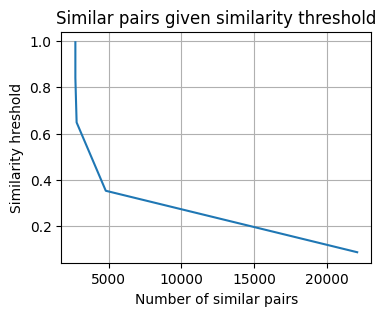

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))
plt.plot(similar_pairs_count, thresholds)

plt.xlabel("Number of similar pairs")
plt.ylabel("Similarity hreshold")
plt.title("Similar pairs given similarity threshold")
plt.grid(True)

plt.show()

Choosing the values of b and r that give us a threshold slightly less than 0.70, so that not only identical pairs of articles are detected

In [17]:
b = 32
r = 8
t = (1/b)**(1/r)
buckets_grouped = lsh_banding(signature_matrix, b, r, n_items)
candidate_pairs = generate_candidate_pairs(buckets_grouped)
similar_pairs = verify_candidates(candidate_pairs, signature_matrix, t, n_hashes)
print(f"Threshold = {t} (b = {b}, r = {r}), number of similar pairs: {similar_pairs.count()}")

Threshold = 0.6484197773255048 (b = 32, r = 8), number of similar pairs: 2782


# Evaluation
Evaluate the estimated similarity by comparing it to the actual Jaccard similarity for all the similar pairs of documents

In [18]:
def jaccard(set1, set2):
  '''Computes the Jaccard similarity given two sets'''
  union = len(set1.union(set2))
  intersection = len(set1.intersection(set2))
  jaccard_sim = intersection / union if union > 0 else 0
  return jaccard_sim

In [19]:
#join the minhash signatures of similar pairs
expanded_pairs_eval = similar_pairs.flatMap(lambda x: [
    (x[0], (x[1], x[2])),
    (x[1], (x[0], x[2]))
])

#join the signatures of similar pairs with the shingles of the correpsonding documents
join_eval = expanded_pairs_eval.join(doc_shingles)

reconstructed_pairs = join_eval.map(lambda x:
 (tuple(sorted(
     (x[0],x[1][0][0]))),
    (x[0],x[1][0][1], x[1][1])
    )).groupByKey()

def comparison(x):
  pair_ids = x[0]
  data = list(x[1])

  if len(data) < 2:
    return None

  data_sorted = sorted(data, key=lambda t: t[0])

  (_, sim_minhash1, set1) = data_sorted[0]
  (_, sim_minhash2, set2) = data_sorted[1]
  sim_minhash = sim_minhash1

  jaccard_sim = jaccard(set1, set2)

  return (pair_ids[0], pair_ids[1], sim_minhash, jaccard_sim, set1, set2)

final_res = reconstructed_pairs.map(comparison).filter(lambda x: x is not None)


Collect the final results and convert them to a Pandas Dataframe to visualize them

In [20]:
comparison_data = final_res.collect()

In [21]:
import pandas as pd
final_df = pd.DataFrame(comparison_data, columns=["doc_i","doc_j","sim_minhash","jaccard","shingles_i","shingles_j"])

final_df.head(30)

,doc_i,doc_j,sim_minhash,jaccard,shingles_i,shingles_j
0,468,2758,1.0,1.0,"{residential sales, recent residential, sales ...","{residential sales, recent residential, sales ..."
1,468,812,1.0,1.0,"{residential sales, recent residential, sales ...","{residential sales, recent residential, sales ..."
2,468,11148,1.0,1.0,"{residential sales, recent residential, sales ...","{residential sales, recent residential, sales ..."
3,468,16336,1.0,1.0,"{residential sales, recent residential, sales ...","{residential sales, recent residential, sales ..."
4,1114,7872,1.0,1.0,"{residential sales, recent residential, sales ...","{residential sales, recent residential, sales ..."
5,7872,13534,1.0,1.0,"{residential sales, recent residential, sales ...","{residential sales, recent residential, sales ..."
6,1792,7872,1.0,1.0,"{residential sales, recent residential, sales ...","{residential sales, recent residential, sales ..."
7,1114,11148,1.0,1.0,"{residential sales, recent residential, sales ...","{residential sales, recent residential, sales ..."
8,11148,13534,1.0,1.0,"{residential sales, recent residential, sales ...","{residential sales, recent residential, sales ..."
9,1472,2430,1.0,1.0,"{closely image, caption join, students see, lo...","{closely image, caption join, students see, lo..."


Compute the Mean Squared Error between the actual Jaccard similarity and the similarity estimated using LSH

In [22]:
final_df["error"] = abs(final_df["jaccard"] - final_df["sim_minhash"])

MAE = final_df["error"].mean()
print(f"MAE: {MAE:.2e}")

final_df.sort_values(by="error", ascending=False)

MAE: 6.72e-04


,doc_i,doc_j,sim_minhash,jaccard,shingles_i,shingles_j,error
874,8357,8362,0.718750,0.666667,"{annual student, category seventh, one top, 9 ...","{annual student, category seventh, one top, 9 ...",0.052083
2562,8359,8362,0.746094,0.700000,"{annual student, category seventh, one top, 9 ...","{annual student, category seventh, one top, 9 ...",0.046094
1067,8359,8361,0.742188,0.700000,"{annual student, category seventh, one top, 9 ...","{tan one, annual student, category seventh, on...",0.042188
251,9555,10759,0.746094,0.705882,"{closed writers, writers offer, stroll lower, ...","{closed writers, writers offer, get cultural, ...",0.040211
1256,9245,9555,0.746094,0.705882,"{closed writers, writers offer, get cultural, ...","{closed writers, writers offer, stroll lower, ...",0.040211
...,...,...,...,...,...,...,...
942,5096,6168,1.000000,1.000000,"{stock market, market business, coronavirus ou...","{stock market, market business, coronavirus ou...",0.000000
943,6168,6744,1.000000,1.000000,"{stock market, market business, coronavirus ou...","{stock market, market business, coronavirus ou...",0.000000
944,6168,8072,1.000000,1.000000,"{stock market, market business, coronavirus ou...","{stock market, market business, coronavirus ou...",0.000000
945,6300,7190,1.000000,1.000000,"{stock market, market business, coronavirus ou...","{stock market, market business, coronavirus ou...",0.000000
